## 1. Import and reading data

In [1]:
import pandas as pd
import sqlite3

In [2]:
db = sqlite3.connect("../data/checking-logs.sqlite")
df = pd.read_sql("SELECT timestamp FROM checker WHERE uid LIKE 'user_%'", db, parse_dates="timestamp")

## 2. Preprocessing data

In [3]:
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour
dow = df['timestamp'].dt.dayofweek
df['kind'] = 'working_day'
df.loc[dow >= 5, 'kind'] = 'weekend'
df.head()

,timestamp,date,hour,kind
0,2020-04-17 05:19:02.744528,2020-04-17,5,working_day
1,2020-04-17 05:22:35.249331,2020-04-17,5,working_day
2,2020-04-17 05:22:45.549397,2020-04-17,5,working_day
3,2020-04-17 05:34:14.691200,2020-04-17,5,working_day
4,2020-04-17 05:34:24.422370,2020-04-17,5,working_day


In [4]:
hour_per_day = (
    df.groupby(['kind', 'date', 'hour'])
      .size()
      .rename('commits')
      .reset_index()
)
hour_per_day

,kind,date,hour,commits
0,weekend,2020-04-18,7,1
1,weekend,2020-04-18,13,5
2,weekend,2020-04-18,14,3
3,weekend,2020-04-18,15,25
4,weekend,2020-04-18,17,7
...,...,...,...,...
283,working_day,2020-05-21,16,4
284,working_day,2020-05-21,17,1
285,working_day,2020-05-21,18,2
286,working_day,2020-05-21,19,8


In [5]:
avg_per_hour = hour_per_day.groupby(['kind', 'hour'], as_index=False)['commits'].mean()
avg_per_hour.head()

,kind,hour,commits
0,weekend,0,2.0
1,weekend,1,6.0
2,weekend,3,1.0
3,weekend,5,2.0
4,weekend,7,4.0


In [10]:
pivot = avg_per_hour.pivot(index='hour', columns='kind', values='commits')
cols = [c for c in ['weekend', 'working_day'] if c in pivot.columns]
pivot = pivot[cols]
pivot.head()

kind,weekend,working_day
hour,,
0,2.0,3.0
1,6.0,NaN
3,1.0,2.0
5,2.0,7.5
6,NaN,1.5


## 3. Creating graph

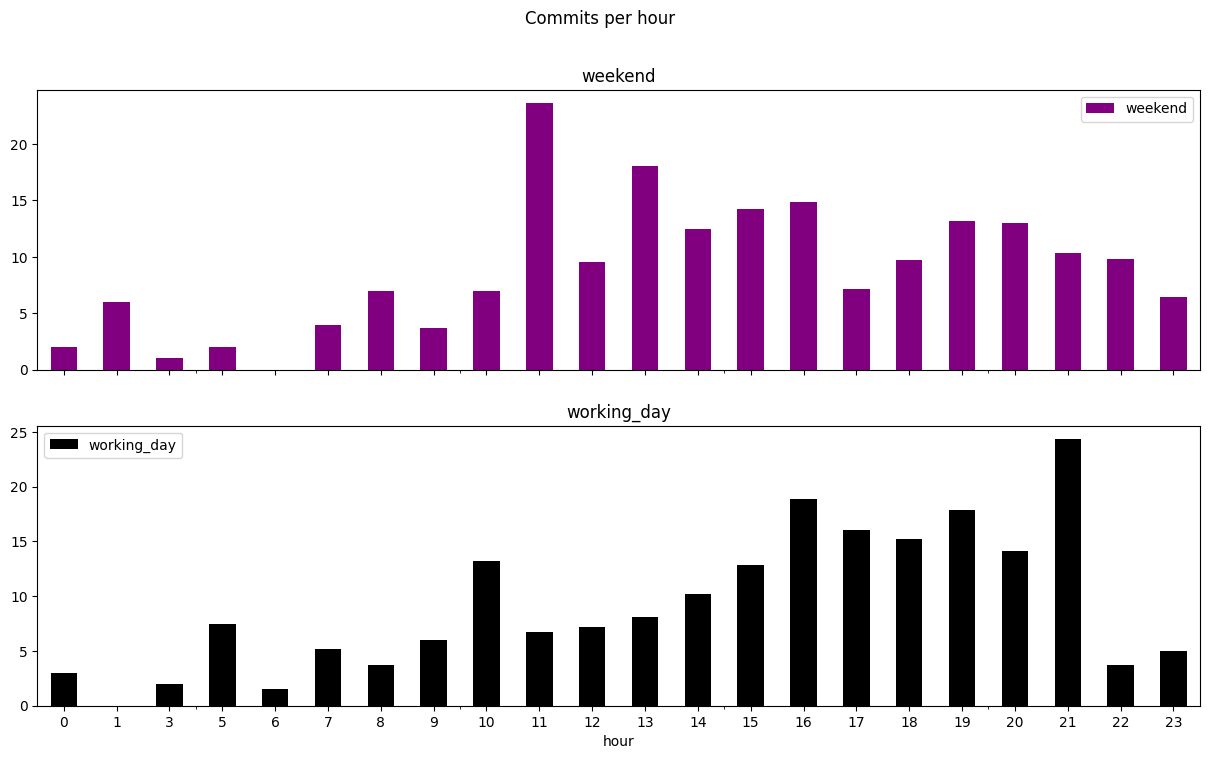

In [14]:
graph = pivot.plot(
    kind='bar',
    subplots=True,
    sharex=True,
    layout=(len(cols), 1),
    figsize=(15,8),
    fontsize=10,
    legend=True,
    rot=0,
    title = "Commits per hour",
    color = ['purple', 'black']
)


## 4. Questions. 
"Is the dynamic different on working days and weekends?"  
### **Да**
- Пик в будни - 21:00
- Пик в выходные - 11:00

## 5. Close

In [8]:
db.close()